In [1]:
import xarray as xr
import numpy as np
from dask.distributed import Client
import glob 
import tqdm
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from sea_breeze import load_model_data
import seaborn as sns
import pandas as pd

def load_barra_static(domain_id,lon_slice,lat_slice):

    """
    Load static variables for a BARRA domain.

    Parameters
    ----------
    domain_id : str
        Identifier for the BARRA domain. Accepted values are "AUST-04", "AUST-11", or "AUS-11".
    lon_slice : slice
        Slice object to restrict the longitude domain.
    lat_slice : slice
        Slice object to restrict the latitude domain.

    Returns
    -------
    orog : xarray.DataArray
        Orography data for the specified domain and region.
    lsm : xarray.DataArray
        Land-sea mask for the specified domain and region, where land is represented by 1 and sea by 0.
    """

    # data_catalog = get_intake_cat_barra()
    # orog = data_catalog.search(variable_id="orog",domain_id=domain_id).to_dask().sel(lon=lon_slice, lat=lat_slice)
    # lsm = data_catalog.search(variable_id="sftlf",domain_id=domain_id).to_dask().sel(lon=lon_slice, lat=lat_slice)

    if domain_id in ["AUST-04"]:
        model = "BARRA-C2"
    elif domain_id in ["AUST-11","AUS-11"]:
        model = "BARRA-R2"
    else:
        raise ValueError("Invalid domain id")

    orog_path = "/g/data/ob53/BARRA2/output/reanalysis/"\
                    +domain_id+"/BOM/ERA5/historical/hres/"+model+\
                        "/v1/fx/orog/latest/"+\
                            "orog_*.nc"
    lsm_path = "/g/data/ob53/BARRA2/output/reanalysis/"\
                    +domain_id+"/BOM/ERA5/historical/hres/"+model+\
                        "/v1/fx/sftlf/latest/"+\
                            "sftlf*.nc"
    orog = xr.open_mfdataset(orog_path).sel(lon=lon_slice, lat=lat_slice)
    lsm = xr.open_mfdataset(lsm_path).sel(lon=lon_slice, lat=lat_slice)

    return orog.orog, (lsm.sftlf >= 50) * 1

In [2]:
client = Client()

In [3]:
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 7
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45673,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:39019,Total threads: 2
Dashboard: /proxy/38901/status,Memory: 9.00 GiB
Nanny: tcp://127.0.0.1:39621,


# Load in hourly sea breeze objects

In [4]:
def preprocess(ds):
    return ds.sel(lat=slice(-12,-11),lon=slice(130,131.5))

sb_obj = xr.open_mfdataset("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/filters/filtered_mask_standard_F_*/",
                           engine="zarr",preprocess=preprocess,chunks={})

In [5]:
sb_obj = sb_obj.persist()

# Domain has been restricted to Tiwis. Also use land-sea mask to just consider objects over the land

In [6]:
orog, lsm = load_barra_static("AUST-04",slice(130,131.5),slice(-12,-11))

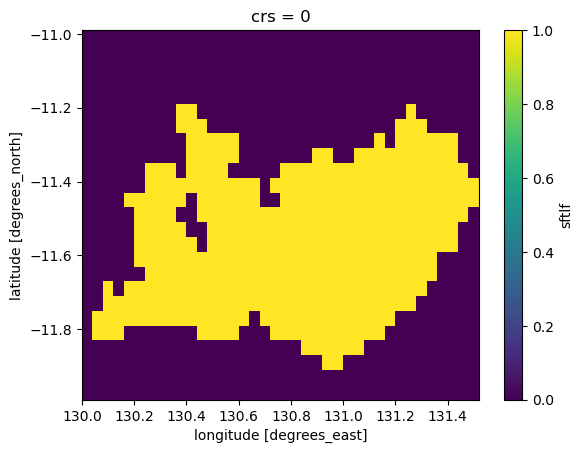

In [7]:
lsm.plot()

In [8]:
sb_obj_land = xr.where(lsm,sb_obj,np.nan)

# Plot spatial map

In [9]:
p1 = slice("1980-01-01 00:00","1984-12-31 23:00")
p2 = slice("1985-01-01 00:00","1989-12-31 23:00")
p3 = slice("1990-01-01 00:00","1994-12-31 23:00")
p4 = slice("1995-01-01 00:00","1999-12-31 23:00")
p5 = slice("2000-01-01 00:00","2004-12-31 23:00")
p6 = slice("2005-01-01 00:00","2009-12-31 23:00")
p7 = slice("2010-01-01 00:00","2014-12-31 23:00")
p8 = slice("2015-01-01 00:00","2019-12-31 23:00")
p9 = slice("2020-01-01 00:00","2024-12-31 23:00")
period_list = [p1,p2,p3,p4,p5,p6,p7,p8,p9]
period_names = [str(p.start[0:4]+"-"+p.stop[0:4]) for p in period_list]

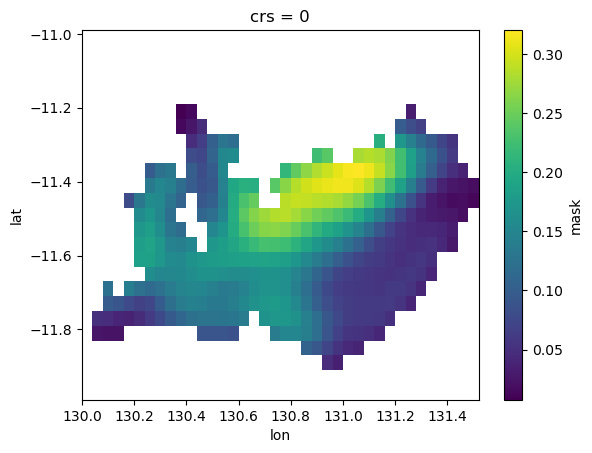

In [21]:
daily_sb_obj_land = sb_obj_land.mask.resample({"time":"1D"}).max().persist()

daily_sb_obj_land.mean("time").plot()

In [23]:
daily_sb_obj_land.sel(time=period_list[0])

<xarray.DataArray 'mask' (lat: 25, lon: 38, time: 1827)> Size: 14MB
dask.array<getitem, shape=(25, 38, 1827), dtype=float64, chunksize=(25, 38, 10), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 200B -11.97 -11.93 -11.89 ... -11.09 -11.05 -11.01
  * lon      (lon) float64 304B 130.0 130.1 130.1 130.1 ... 131.4 131.5 131.5
    crs      int32 4B ...
  * time     (time) datetime64[ns] 15kB 1980-01-01 1980-01-02 ... 1984-12-31

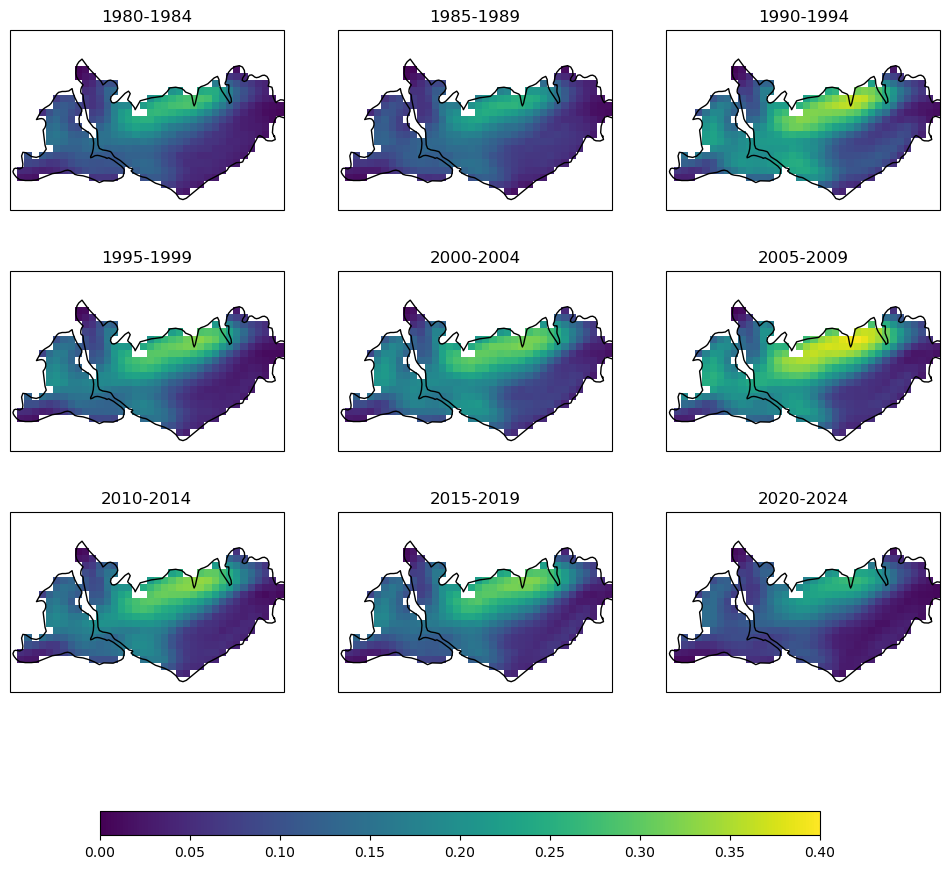

In [32]:
plt.figure(figsize=[12,12])
cnt=1
for p,n in zip(period_list,period_names):
    ax=plt.subplot(4,3,cnt,projection=ccrs.PlateCarree())
    temp = daily_sb_obj_land.sel(time=p).mean("time")
    c=temp.plot(vmin=0,vmax=0.4,extend="max",add_colorbar=False)
    plt.title(n)
    ax.coastlines()
    cnt = cnt+1

plt.colorbar(c,plt.axes([0.2,0.2,0.6,0.02]),orientation="horizontal")

In [36]:
sb_obj_hour_mean = sb_obj_land.groupby(sb_obj_land.time.dt.hour).mean().persist()


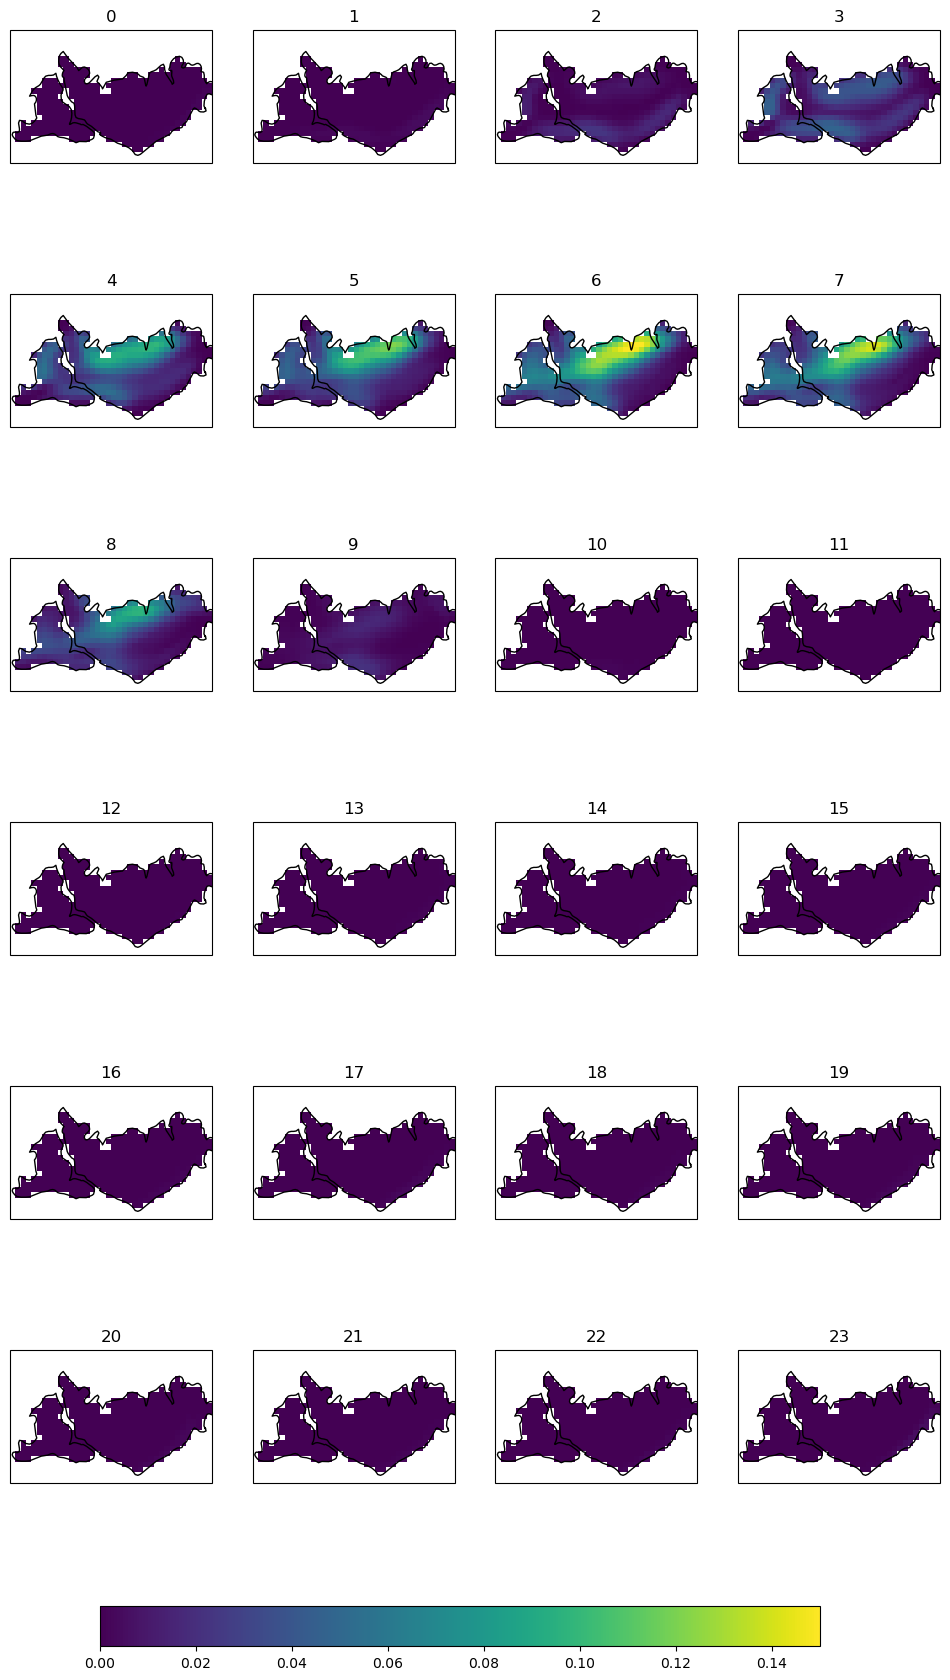

In [44]:
plt.figure(figsize=[12,20])
cnt=1
for h in np.arange(0,24):
    ax=plt.subplot(6,4,cnt,projection=ccrs.PlateCarree())
    c=sb_obj_hour_mean.sel(hour=h).mask.plot(vmin=0,vmax=0.15,extend="max",add_colorbar=False)
    plt.title(str(h))
    ax.coastlines()
    cnt = cnt+1

plt.colorbar(c,plt.axes([0.2,0.05,0.6,0.02]),orientation="horizontal")

# Convert to a time series of sea breeze occurrence anywhere over the land

In [9]:
sb_df = sb_obj_land.mask.max(("lat","lon")).to_dataframe()

# Plot some data

### Diurnal timing of object identification

Text(0.5, 1.0, 'Hourly sea breeze occurrence histogram')

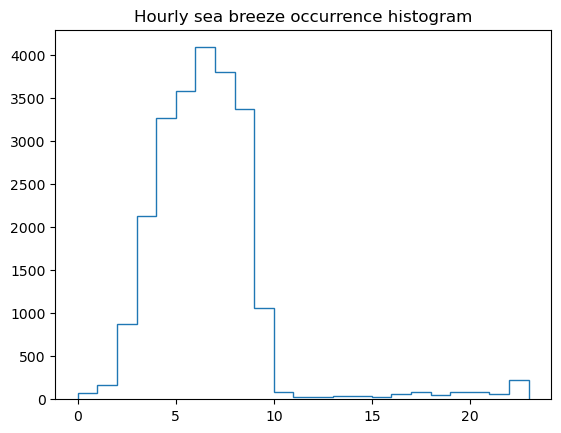

In [10]:
plt.hist(sb_df.query("mask==1").index.hour,bins=np.arange(0,24),histtype="step");
plt.title("Hourly sea breeze occurrence histogram")

Text(0.5, 1.0, 'Hourly sea breeze occurrence histogram for 5 year slices')

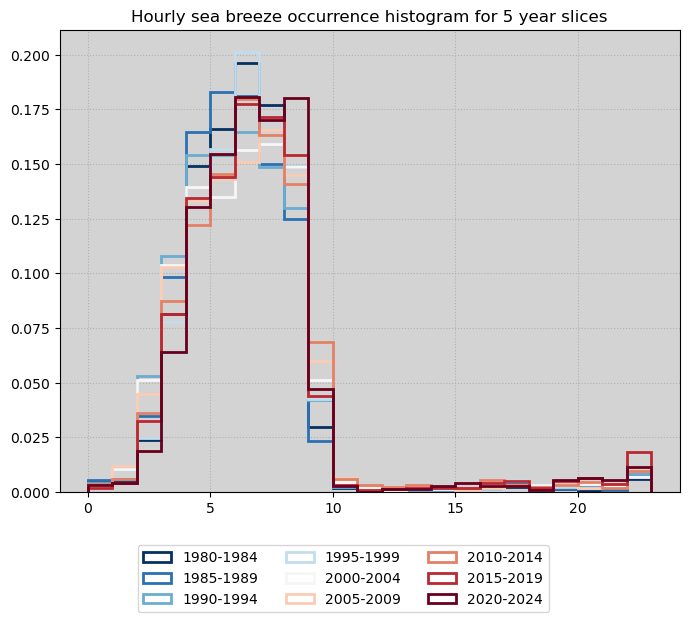

In [11]:


plt.figure(figsize=[8,6])

plt.gca().set_facecolor("lightgrey")
plt.gca().grid(ls=":")

[plt.hist(sb_df.loc[p].query("mask==1").index.hour,bins=np.arange(0,24),histtype="step",density=True,label=p,color=plt.get_cmap("RdBu_r")(i),lw=2) for p,i in zip(period_list,np.linspace(0,1,len(period_list)))]

plt.legend(labels=period_names,bbox_to_anchor=(0.8,-0.1),ncols=3)
plt.title("Hourly sea breeze occurrence histogram for 5 year slices")

Text(0.5, 1.0, 'Hourly sea breeze occurrence histogram for 5 year slices')

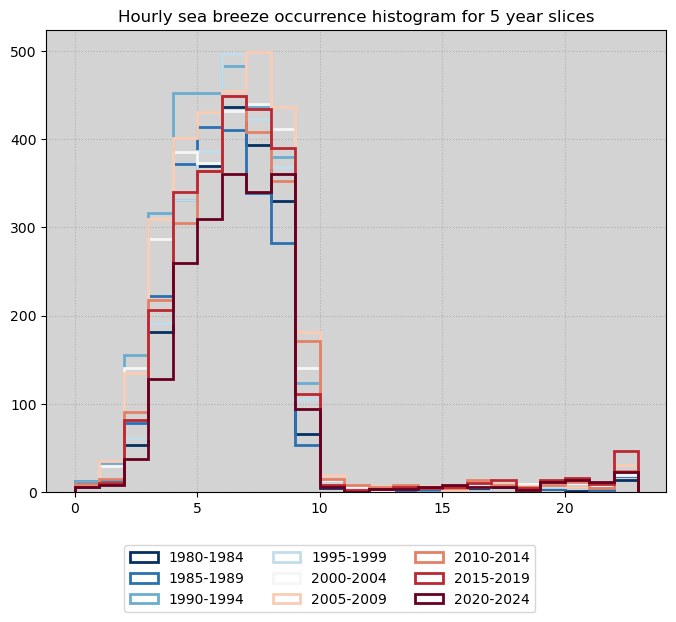

In [13]:
plt.figure(figsize=[8,6])

plt.gca().set_facecolor("lightgrey")
plt.gca().grid(ls=":")

[plt.hist(sb_df.loc[p].query("mask==1").index.hour,bins=np.arange(0,24),histtype="step",density=False,label=p,color=plt.get_cmap("RdBu_r")(i),lw=2) for p,i in zip(period_list,np.linspace(0,1,len(period_list)))]

plt.legend(labels=period_names,bbox_to_anchor=(0.8,-0.1),ncols=3)
plt.title("Hourly sea breeze occurrence histogram for 5 year slices")

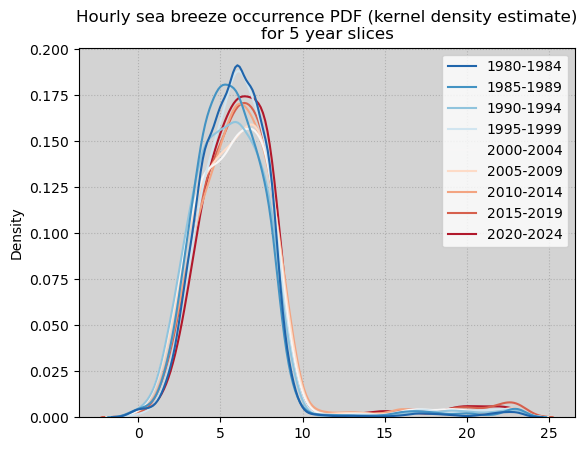

In [12]:
data = pd.concat([pd.DataFrame({n:sb_df.loc[p].query("mask==1").index.hour}) for p,n in zip(period_list,period_names)])

plt.gca().set_facecolor("lightgrey")
plt.gca().grid(ls=":")
sns.kdeplot(data,palette="RdBu_r",legend=True,common_norm=False)
plt.title("Hourly sea breeze occurrence PDF (kernel density estimate)\nfor 5 year slices");

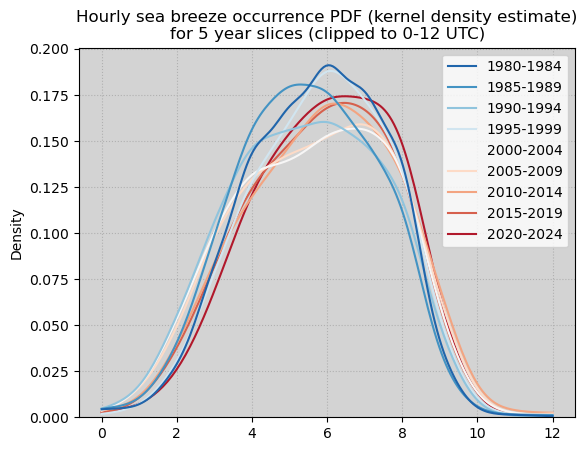

In [13]:
data = pd.concat([pd.DataFrame({n:sb_df.loc[p].query("mask==1").index.hour}) for p,n in zip(period_list,period_names)])

plt.gca().set_facecolor("lightgrey")
plt.gca().grid(ls=":")
sns.kdeplot(data,palette="RdBu_r",legend=True,clip=[0,12],common_norm=False)
plt.title("Hourly sea breeze occurrence PDF (kernel density estimate)\nfor 5 year slices (clipped to 0-12 UTC)");

### Seasonal cycle

We define sea breeze days here (`sb_day`) as a binary time series of if there is at least one object over the Tiwis

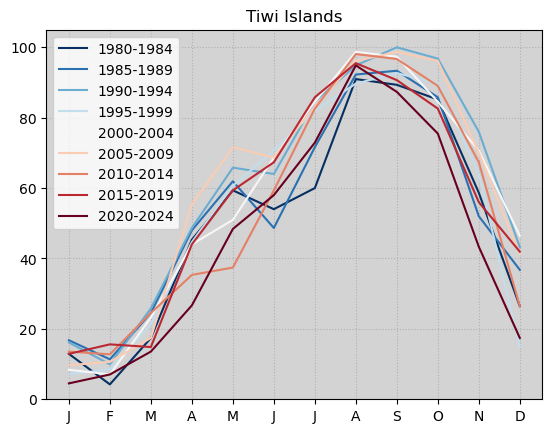

In [14]:
def plot(ax,df,title,legend,color):

    l1=(df["mask"].groupby(df.index.month).mean() * 100).plot(marker="none",ax=ax,legend=False,label=legend,color=color)
        
    ax.set_ylim([0,105])
    ax.set_title(title)
    ax.grid(ls=":")
    ax.set_xlabel("")
    ax.set_xticks(np.arange(1,13),["J","F","M","A","M","J","J","A","S","O","N","D"])

    return l1

sb_day = sb_df.resample("1D").max()

ax=plt.axes()
[plot(ax,sb_day.loc[p],"Tiwi Islands",n,color=plt.get_cmap("RdBu_r")(i)) for p,n,i in zip(period_list,period_names,np.linspace(0,1,len(period_names)))];
plt.legend()

plt.gca().set_facecolor("lightgrey")
plt.gca().grid(ls=":")

### Yearly variations and trends

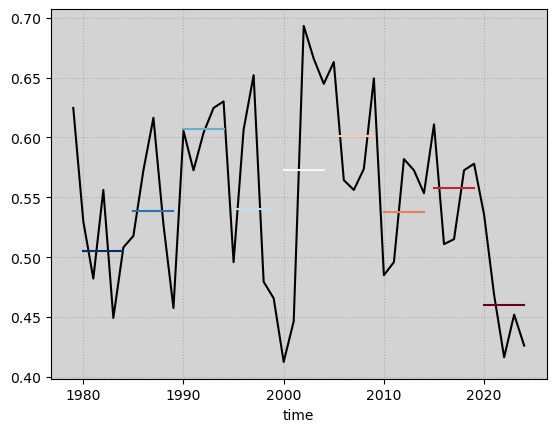

In [15]:
sb_day.groupby(sb_day.index.year).mean()["mask"].plot(color="k")
[plt.plot([int(p.start[0:4]),int(p.stop[0:4])],
          [sb_day.loc[p].mean()["mask"],sb_day.loc[p].mean()["mask"]],label=n,color=plt.get_cmap("RdBu_r")(i)) for p,n,i in zip(period_list,period_names,np.linspace(0,1,len(period_names)))];
plt.gca().set_facecolor("lightgrey")
plt.gca().grid(ls=":")

### Trends in intensity

Currently only have the following stats saved:
* Mean land sea temperature difference (defined as difference between warmest land temp within 50 km of sea breeze object, and temp of closest ocean point)
* Mean onshore wind over the sea breeze object/front


In [16]:
#Get file paths for all dfs
df_files = np.sort(glob.glob("/g/data/ng72/ab4502/sea_breeze_detection/barra_c_smooth_s2/props_df/props_df_standard_F_*.csv"))

#Initialise list of Tiwi dfs
tiwi_df_ls = []

#Loop through dfs
for f in tqdm.tqdm(df_files):

    #Load in the current df
    temp_df = pd.read_csv(f).sort_values("time_utc")

    #Restrict lat lons to Tiwis
    temp_df = temp_df[(temp_df["lon_centroid"]>=130) & (temp_df["lon_centroid"]<=131.5) & (temp_df["lat_centroid"]>=-12) & (temp_df["lat_centroid"]<=-11)]

    #Append to list
    tiwi_df_ls.append(temp_df)

#End loop - drop duplicates
tiwi_df = pd.concat(tiwi_df_ls)

100%|██████████| 1978/1978 [00:19<00:00, 104.05it/s]


In [17]:
#Convert time column to a datetime
tiwi_df["time_utc"] = pd.to_datetime(tiwi_df.time_utc,format='mixed')

Quick check to see that the statistics .csv files matches the object .zarr files

Note there are some differences are lat/lon centroids are used to locate objects over Tiwis (land and sea)

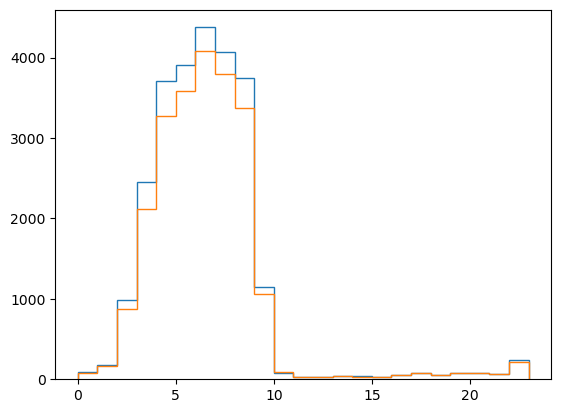

In [18]:
plt.hist(tiwi_df.time_utc.dt.hour,bins=np.arange(0,24),histtype="step",label="Object times from .csv");
plt.hist(sb_df.query("mask==1").index.hour,bins=np.arange(0,24),histtype="step",label="Object times from .zarr files");

Text(0.5, 1.0, 'Relationship between mean onshore wind (averaged over object) and \nland-sea temperature difference')

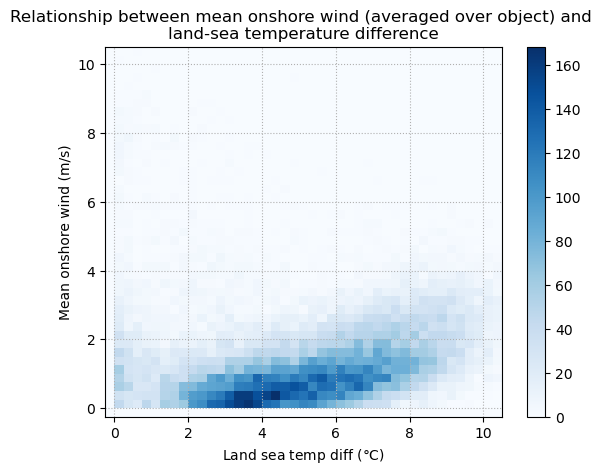

In [19]:
plt.hist2d(tiwi_df["mean_land_sea_temp_diff"],tiwi_df["mean_vprime"],bins=[np.arange(-0.25,10.75,0.25),np.arange(-0.25,10.75,0.25)],cmap="Blues");
plt.xlabel("Land sea temp diff ($\degree$C)")
plt.ylabel("Mean onshore wind (m/s)")
plt.gca().grid(ls=":")
plt.colorbar()

plt.title("Relationship between mean onshore wind (averaged over object) and \nland-sea temperature difference")

In [20]:
temp_df_ls = []
for p,n in zip(period_list,period_names):
    temp_df = tiwi_df[(tiwi_df.time_utc>=p.start) & (tiwi_df.time_utc<=p.stop)][["mean_land_sea_temp_diff","mean_vprime","mean_q_change","time_utc"]]
    temp_df["period"] = n
    temp_df_ls.append(temp_df.reset_index())

intensity_df = pd.concat(temp_df_ls,axis=0)

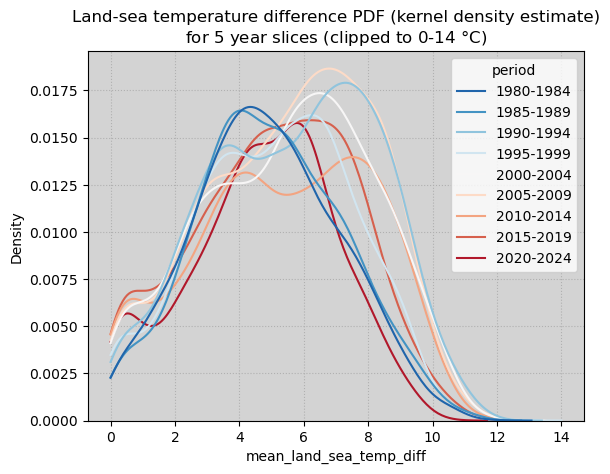

In [21]:
plt.gca().set_facecolor("lightgrey")
plt.gca().grid(ls=":")
sns.kdeplot(intensity_df,x="mean_land_sea_temp_diff",palette="RdBu_r",hue="period",legend=True,clip=[0,14])
plt.title("Land-sea temperature difference PDF (kernel density estimate)\nfor 5 year slices (clipped to 0-14 $\degree$C)");

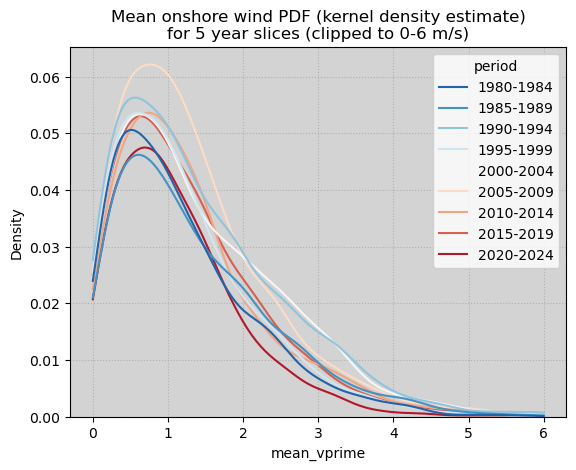

In [22]:
plt.gca().set_facecolor("lightgrey")
plt.gca().grid(ls=":")
sns.kdeplot(intensity_df,x="mean_vprime",palette="RdBu_r",hue="period",legend=True,clip=[0,6])
plt.title("Mean onshore wind PDF (kernel density estimate)\nfor 5 year slices (clipped to 0-6 m/s)");

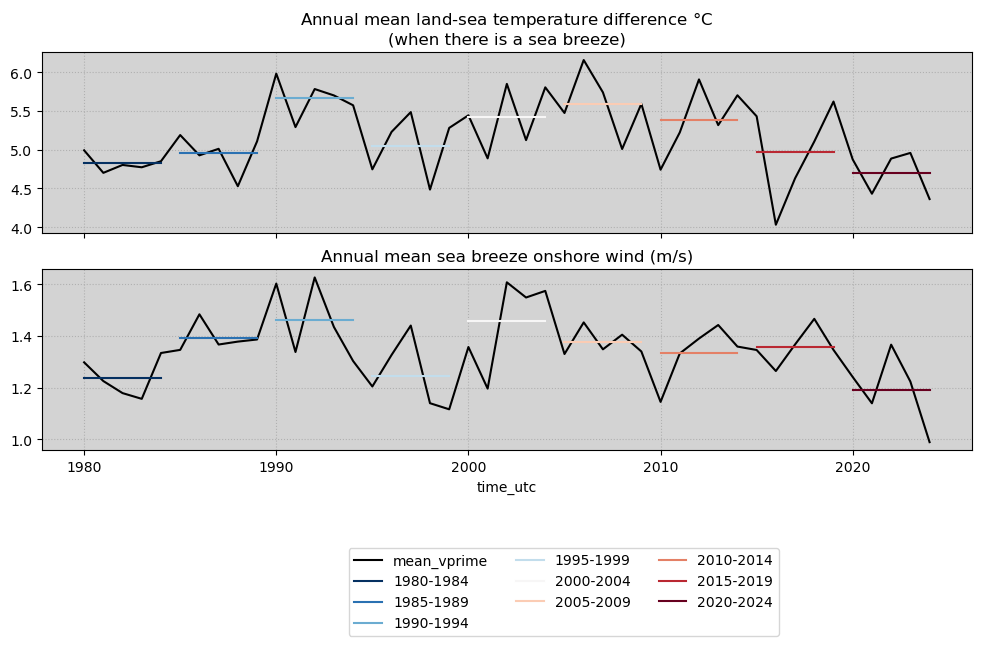

In [23]:
period_list_yearly = [slice(int(p.start[0:4]),int(p.stop[0:4])) for p in period_list]

yearly_intensity = intensity_df.groupby(intensity_df.time_utc.dt.year)[["mean_land_sea_temp_diff","mean_vprime"]].mean()

plt.figure(figsize=[12,8])

plt.subplot(3,1,1)
yearly_intensity.mean_land_sea_temp_diff.plot(label=None,color="k",legend=False)

[plt.plot([p.start,p.stop],
          [yearly_intensity.loc[p].mean()["mean_land_sea_temp_diff"],yearly_intensity.loc[p].mean()["mean_land_sea_temp_diff"]],
          label=n,color=plt.get_cmap("RdBu_r")(i)) for p,n,i in zip(period_list_yearly,period_names,np.linspace(0,1,len(period_names)))];

plt.gca().set_xticklabels("")
plt.xlabel("")
plt.title("Annual mean land-sea temperature difference $\degree$C\n(when there is a sea breeze)")

plt.gca().set_facecolor("lightgrey")
plt.gca().grid(ls=":")

plt.subplot(3,1,2)
yearly_intensity.mean_vprime.plot(label=None,color="k",legend=False)

[plt.plot([p.start,p.stop],
          [yearly_intensity.loc[p].mean()["mean_vprime"],yearly_intensity.loc[p].mean()["mean_vprime"]],
          label=n,color=plt.get_cmap("RdBu_r")(i)) for p,n,i in zip(period_list_yearly,period_names,np.linspace(0,1,len(period_names)))];

plt.title("Annual mean sea breeze onshore wind (m/s)")

plt.gca().set_facecolor("lightgrey")
plt.gca().grid(ls=":")

plt.legend(bbox_to_anchor=(0.8,-0.5),ncols=3)

### Trends in the timing of the land-sea temperature contrast?

Text(0.5, 1.0, 'Hourly average land-sea temperature contrast\n(when there is a sea breeze')

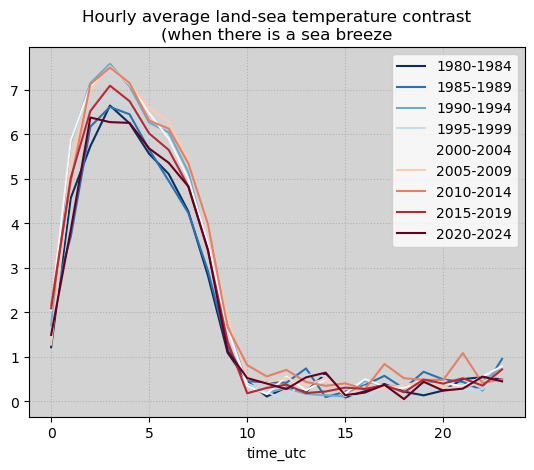

In [24]:
ax=plt.axes()
for n,i in zip(period_names,np.linspace(0,1,len(period_names))):
    
    temp_intensity_df = intensity_df[intensity_df.period==n]
    temp_intensity_df.groupby(temp_intensity_df.time_utc.dt.hour)["mean_land_sea_temp_diff"].mean().plot(ax=ax,color=plt.get_cmap("RdBu_r")(i),label=n)

plt.gca().set_facecolor("lightgrey")
plt.gca().grid(ls=":")
plt.legend()

plt.title("Hourly average land-sea temperature contrast\n(when there is a sea breeze")